In [1]:
#!/usr/bin/env python3
import numpy as np
import os
from pathlib import Path
import tqdm
import logging
from computeEfficiencies import getObjects

FORMAT = '%(levelname)s: %(message)s'
logging.basicConfig(format=FORMAT,datefmt='%m/%d/%Y %I:%M:%S %p')
logger = logging.getLogger()   

# Fix seed so results are reproducible!
np.random.seed(seed=123)

DelphesLLP_path = Path(os.path.abspath("./DelphesLLP"))
os.environ['ROOT_INCLUDE_PATH'] = os.path.join(DelphesLLP_path,"external")

import ROOT
ROOT.gSystem.Load(os.path.join(DelphesLLP_path,"libDelphes.so"))
ROOT.gInterpreter.Declare('#include "classes/SortableObject.h"')
ROOT.gInterpreter.Declare('#include "classes/DelphesClasses.h"')
ROOT.gInterpreter.Declare('#include "external/ExRootAnalysis/ExRootTreeReader.h"')
from ROOT import TFile


import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams.update({"savefig.dpi" : 300}) #Figure resolution


#Define plotting style:
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']
cm_rev = plt.colormaps['RdYlBu_r']

Welcome to JupyROOT 6.30/06


In [2]:
def getData(inputFile,pt_target_bias,pt_bias_power,bias_min):
    f = TFile(inputFile,'read')
    DelphesTree = f.Get('Delphes')
    nevts = DelphesTree.GetEntries()

    totalweight = 0.0
    totalweight0 = 0.0
    ct=0

    llp_pTs = []
    weights = []
    weights0 = []

    disable = True
    for entry in tqdm.tqdm(range(nevts),position=0,
                            desc=inputFile,
                            leave=False,
                            disable=disable):
        DelphesTree.GetEntry(entry)
        weight = float(DelphesTree.Weight.At(0).Weight)
        weights0.append(weight)
        totalweight0 += weight

        if pt_bias_power != 0.0:
            # Only the heavy partons are used for the bias
            heavy_partons = [ptc for ptc in DelphesTree.FilterParticle 
                              if (ptc.Mass > 10.0 and abs(ptc.Status) in [22,23])]
            
            pTmax = bias_min
            pTmax = max(pTmax,max([ptc.PT for ptc in heavy_partons]))
            if pTmax > 0.0:
                bias_weight = (pTmax/pt_target_bias)**pt_bias_power
                weight = weight/bias_weight

        weights.append(weight)
        totalweight += weight
        
        ct+=1
        llps = list(DelphesTree.bsm)
        pts = [0.0,0.0]
        for llp in llps:
            if llp.PID == 1000024:
                pts[0] = llp.PT
            elif llp.PID == -1000024:
                pts[1] = llp.PT    
        llp_pTs.append(pts)
    #End of loop
    f.Close()
    return np.array(llp_pTs),np.array(weights)

# Chargino-Chargino Production

In [18]:
inputFile = './pp2chgchg_test/Events/run_02/wino_1000GeV_0.010ns_delphes_events.root'
pt_target_bias = 1000.0
pt_bias_power = 4.0
pt_bias_min = 50.0
llp_pTs_bias,weights_bias = getData(inputFile,pt_bias_power=pt_bias_power,pt_target_bias=pt_target_bias,bias_min=pt_bias_min)
print(sum(weights_bias)/len(weights_bias),sum(weights_bias)/50000)

0.0006401333262115478 0.00047540141604426807


In [21]:
inputFile = './pp2chgchg_test0/Events/run_02/wino_1000GeV_0.010ns_delphes_events.root'
llp_pTs,weights = getData(inputFile,pt_bias_power=0.0,pt_target_bias=1.0,bias_min=0.0)
print(sum(weights)/len(weights),sum(weights)/50000)

0.0006797909154556692 0.000508048538574949


In [22]:
colors= ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

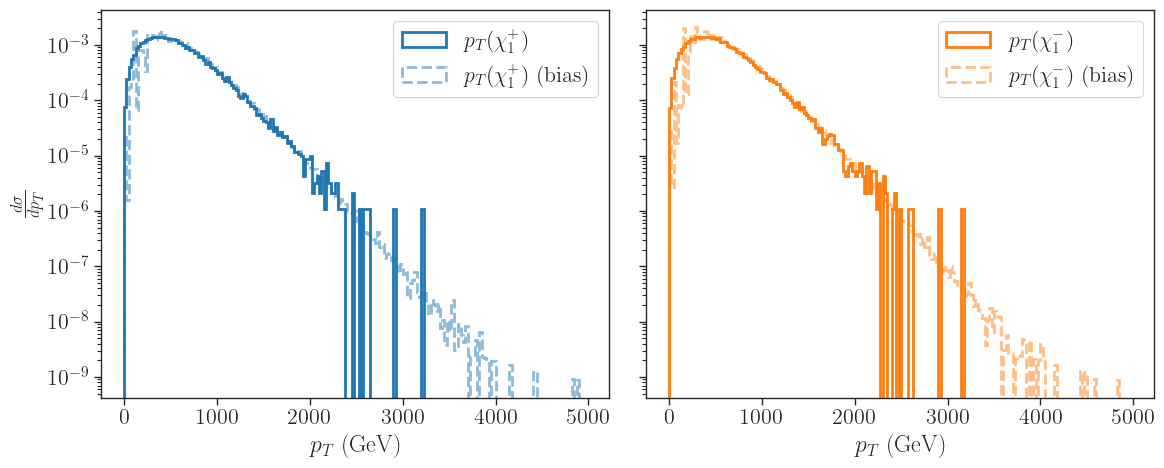

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

bins = np.arange(0., 5000., 25.)

# --- Left subplot: unbiased ---
axes[0].hist(
    llp_pTs[:, 0],
    label=r'$p_T (\chi_1^+)$',
    bins=bins,
    histtype='step',
    weights=weights,
    color=colors[0],
    linewidth=2,
    density=True
)

axes[1].hist(
    llp_pTs[:, 1],
    label=r'$p_T (\chi_1^-)$',
    bins=bins,
    histtype='step',
    weights=weights,
    color=colors[1],
    linewidth=2,
    density=True
)



# --- Right subplot: biased ---
axes[0].hist(
    llp_pTs_bias[:, 0],
    label=r'$p_T (\chi_1^+)$ (bias)',
    bins=bins,
    histtype='step',
    weights=weights_bias,
    color=colors[0],
    linewidth=2,
    linestyle='dashed',
    density=True,
    alpha=0.5
)

axes[1].hist(
    llp_pTs_bias[:, 1],
    label=r'$p_T (\chi_1^-)$ (bias)',
    bins=bins,
    histtype='step',
    weights=weights_bias,
    color=colors[1],
    linewidth=2,
    linestyle='dashed',
    density=True,
    alpha=0.5
)

# axes[0].set_title('Unbiased')
axes[0].legend()
axes[0].set_yscale('log')
axes[0].set_xlabel(r'$p_T$ (GeV)')
axes[0].set_ylabel(r'$\frac{d\sigma}{d p_T}$')

# axes[1].set_title('Biased')
axes[1].legend()
axes[1].set_yscale('log')
axes[1].set_xlabel(r'$p_T$ (GeV)')

plt.tight_layout()
plt.show()


# Chargino-Neutralino Production

In [31]:
# inputFile = './pp2chgn1_test/Events/run_01/wino_100GeV_0.300ns_delphes_events.root'
# pt_target_bias = 1000.0
# pt_bias_power = 4.0
inputFile = './pp2chgn1_test/Events/run_07/wino_1000GeV_0.010ns_delphes_events.root'
pt_target_bias = 10000.0
pt_bias_power = 4.0
pt_bias_min = 50.0
llp_pTs_bias,weights_bias = getData(inputFile,pt_bias_power=pt_bias_power,pt_target_bias=pt_target_bias,bias_min=pt_bias_min)
print(sum(weights_bias)/len(weights_bias),sum(weights_bias)/50000)

0.0013942200231219462 0.0010330054995315125


In [32]:
inputFile = './pp2chgn1_test0/Events/run_02/wino_1000GeV_0.010ns_delphes_events.root'
llp_pTs,weights = getData(inputFile,pt_bias_power=0.0,pt_target_bias=1.0,bias_min=0.0)
print(sum(weights)/len(weights),sum(weights)/50000)

0.0014974090736359358 0.0011293758715176954


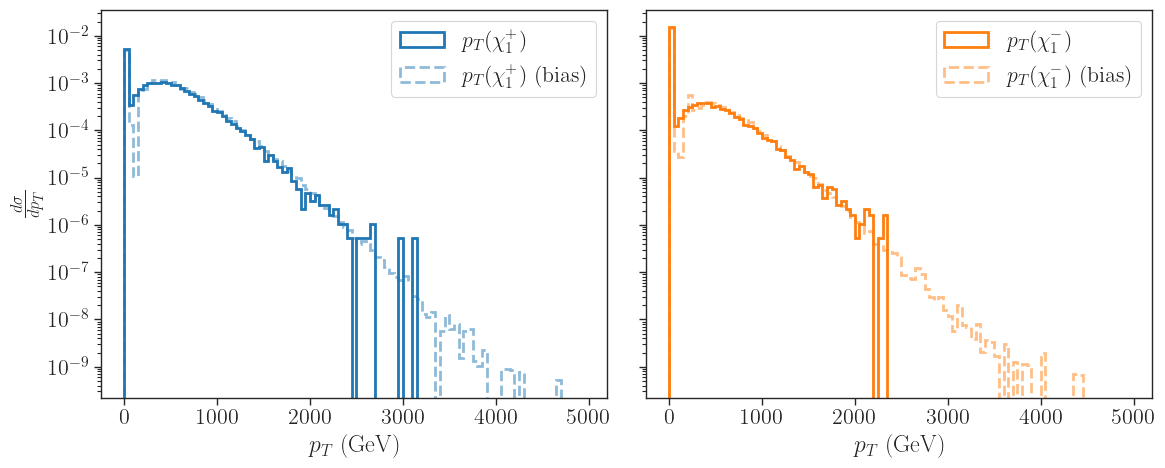

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

bins = np.arange(0., 5000., 50.)

# --- Left subplot: unbiased ---
axes[0].hist(
    llp_pTs[:, 0],
    label=r'$p_T (\chi_1^+)$',
    bins=bins,
    histtype='step',
    weights=weights,
    color=colors[0],
    linewidth=2,
    density=True
)

axes[1].hist(
    llp_pTs[:, 1],
    label=r'$p_T (\chi_1^-)$',
    bins=bins,
    histtype='step',
    weights=weights,
    color=colors[1],
    linewidth=2,
    density=True
)



# --- Right subplot: biased ---
axes[0].hist(
    llp_pTs_bias[:, 0],
    label=r'$p_T (\chi_1^+)$ (bias)',
    bins=bins,
    histtype='step',
    weights=weights_bias,
    color=colors[0],
    linewidth=2,
    linestyle='dashed',
    density=True,
    alpha=0.5
)

axes[1].hist(
    llp_pTs_bias[:, 1],
    label=r'$p_T (\chi_1^-)$ (bias)',
    bins=bins,
    histtype='step',
    weights=weights_bias,
    color=colors[1],
    linewidth=2,
    linestyle='dashed',
    density=True,
    alpha=0.5
)

# axes[0].set_title('Unbiased')
axes[0].legend()
axes[0].set_yscale('log')
axes[0].set_xlabel(r'$p_T$ (GeV)')
axes[0].set_ylabel(r'$\frac{d\sigma}{d p_T}$')

# axes[1].set_title('Biased')
axes[1].legend()
axes[1].set_yscale('log')
axes[1].set_xlabel(r'$p_T$ (GeV)')

plt.tight_layout()
plt.show()
